# B560: Seminar Advanced Topics in Asset Management

#### Student: Moritz Maidl 6952271

## Part 1: Environment & Data Preparation

### 1.1. Package Imports & Configuration

Imports libraries for data manipulation (Pandas/Numpy), statistics (SciPy/Statsmodels), visualization (Matplotlib/Seaborn), and Deep Learning (PyTorch). It also sets global seeds for reproducibility.

In [1]:
import os                                    # env vars, paths, OS helpers
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # avoids OMP/MKL duplicate symbol error on some setups

# Standard library
from datetime import datetime                # explicit datetime ops when needed
import warnings                              # control noisy warnings

# Core numerics & data wrangling
import numpy as np                           # fast numerical arrays, vectorization
import pandas as pd                          # tabular data, I/O, time series handling

# Plotting
import matplotlib.pyplot as plt              # figures/plots
import matplotlib.dates as mdates            # date tick/locator formatters
import seaborn as sns                        # cleaner statistical plots

# Statistics & Econometrics
import scipy.stats as stats                  # general statistical routines (skew, kurtosis, etc.)
from scipy.stats import norm, chi2, binom    # specific distributions for tests/CIs
import statsmodels.api as sm                 # econometrics (OLS, QuantReg, etc.)
from statsmodels.tsa.stattools import adfuller              # Stationarity (ADF) test
from statsmodels.stats.diagnostic import het_arch           # ARCH-LM test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Autocorrelation plots

# ARCH/GARCH family
from arch.univariate import arch_model                     # univariate (E)GARCH estimation
from arch.univariate.distribution import SkewStudent       # skew-t innovations for VaR
from arch.__future__ import reindexing                     # consistent future reindexing behavior

# PyTorch (Deep Learning)
import torch                                               # tensors, CUDA
import torch.nn as nn                                      # neural-network layers
from torch.utils.data import TensorDataset, DataLoader     # dataset & mini-batch loaders

# Utilities
from IPython.display import display          # for rendering clean tables in notebooks

# Configuration
warnings.filterwarnings("ignore")            # Suppress warnings for cleaner output
sns.set_theme(style="whitegrid")             # Apply default seaborn styling

### 1.2. Data Loading, Cleaning, and Sample Splitting

Loads the data_eur_stoxx_50.csv, computes daily log-returns, and defines the Train (1996-2012), Validation (2013-2015), and Test (2016+) temporal masks used throughout the notebook.

In [2]:
SEED = 42
np.random.seed(SEED)

df_raw = pd.read_csv("data_eur_stoxx_50.csv", sep=";")

# Handle European decimal formatting (commas -> dots) for financial columns
cols_to_fix = [c for c in ["open", "high", "low", "close"] if c in df_raw.columns]
for col in cols_to_fix:
    if df_raw[col].dtype == 'object':
        df_raw[col] = (df_raw[col].astype(str)
                                  .str.replace(",", ".", regex=False)
                                  .astype(float))

df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

df = df_raw.set_index("date").copy()
df["log_return"] = np.log(df["close"]).diff()
df = df.dropna(subset=["log_return"])

r = df["log_return"].astype(float)
r.name = "r"

# Define temporal splits 
TRAIN_START = pd.Timestamp("1996-01-01")
VAL_START   = pd.Timestamp("2013-01-01")
PRETEST_END = pd.Timestamp("2015-12-31")
TEST_START  = pd.Timestamp("2016-01-04")
TEST_END    = r.index.max()

mask_pretest = (r.index >= TRAIN_START) & (r.index <= PRETEST_END)  # train + validation
mask_test    = (r.index >= TEST_START)  & (r.index <= TEST_END)

print("Number of observations:")
print(f" Total: {len(r)}")
print(f" Pre-test: {mask_pretest.sum()}")
print(f" Test: {mask_test.sum()}")

Number of observations:
 Total: 7449
 Pre-test: 5138
 Test: 2311


### 1.3. Visualizing the Market Regime

Plots the Euro Stoxx 50 index level, daily log-returns, and the return distribution histogram with shaded regions indicating the Train/Val/Test splits.

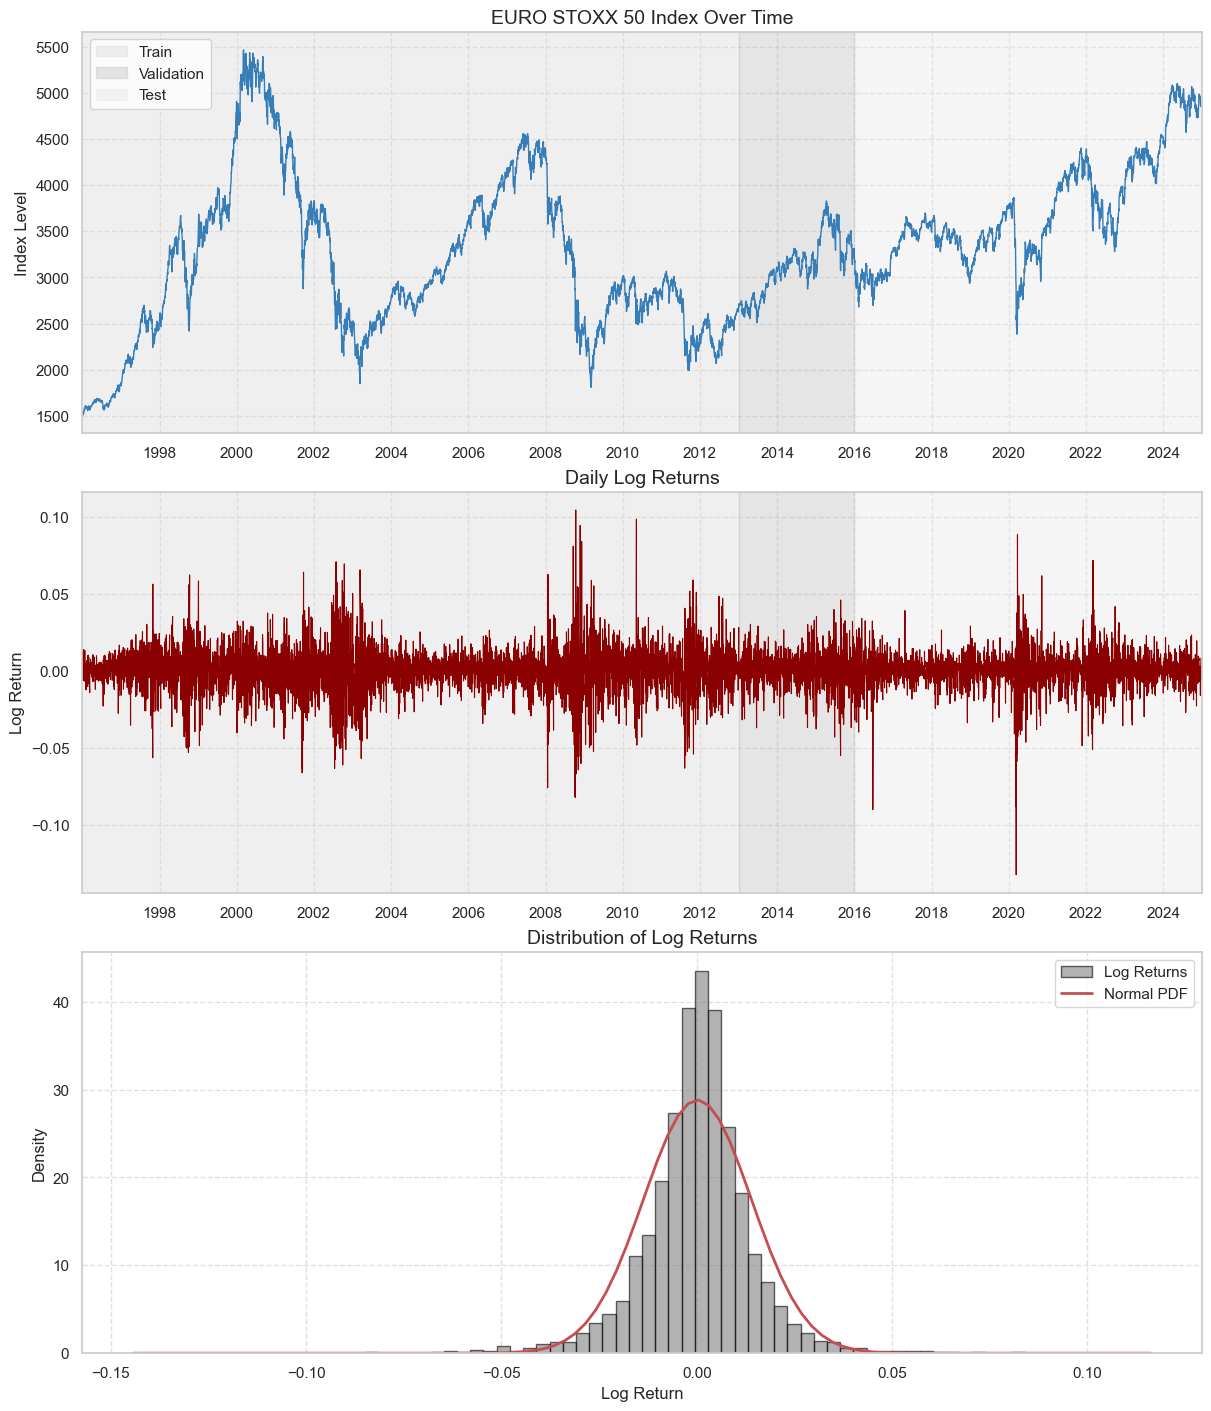

In [3]:
def add_shaded_regions(ax):
    ax.axvspan(TRAIN_START, VAL_START, color='#d9d9d9', alpha=0.4, label='Train')
    ax.axvspan(VAL_START, PRETEST_END, color='#bfbfbf', alpha=0.4, label='Validation')
    ax.axvspan(TEST_START, TEST_END, color='#e6e6e6', alpha=0.4, label='Test')

fig, axes = plt.subplots(3, 1, figsize=(12, 14), constrained_layout=True)

# Plot 1: Index Level
ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#377eb8', linewidth=1)
add_shaded_regions(ax1)
ax1.set_title("EURO STOXX 50 Index Over Time", fontsize=14)
ax1.set_ylabel("Index Level")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# Plot 2: Daily Log Returns
ax2 = axes[1]
ax2.plot(df.index, df['log_return'], color='#8b0000', linewidth=0.8)
add_shaded_regions(ax2)
ax2.set_title("Daily Log Returns", fontsize=14)
ax2.set_ylabel("Log Return")
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Distribution of Log Returns (Histogram + Normal Fit)
ax3 = axes[2]
n, bins, patches = ax3.hist(df['log_return'], bins=70, density=True,
                            color='grey', alpha=0.6, edgecolor='black', label='Log Returns')

mu, std = stats.norm.fit(df['log_return'])
xmin, xmax = ax3.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax3.plot(x, p, 'r', linewidth=2, label='Normal PDF')

ax3.set_title("Distribution of Log Returns", fontsize=14)
ax3.set_xlabel("Log Return")
ax3.set_ylabel("Density")
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.6)

# Formatting the Date Axis for plots 1 and 2
for ax in [ax1, ax2]:
    ax.set_xlim(df.index.min(), df.index.max())
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

## Part 2: Stylized Facts (Justifying the Model)

### 2.1. Descriptive Statistics & Stationarity Tests

Calculates skewness, kurtosis, and Jarque-Bera statistics to confirm non-normality, and runs the Augmented Dickey-Fuller test to confirm the stationarity of returns.

In [4]:
r = df['log_return'].astype(float)

print("Descriptive statistics for daily log-returns (levels):")
print(r.describe().to_string())
print()

# Skewness and kurtosis (Check for non-normality / heavy tails)
skew = stats.skew(r, bias=False)
kurt = stats.kurtosis(r, fisher=False, bias=False) # Pearson kurtosis, normal = 3

# Jarque-Bera normality test
jb_stat, jb_p = stats.jarque_bera(r)

print(f"Skewness: {skew:.4f}")
print(f"Kurtosis (Pearson): {kurt:.4f}")
print(f"Jarque-Bera: stat = {jb_stat:.2f}, p-value = {jb_p:.4e}")

# Augmented Dickey-Fuller test
# Tests the null hypothesis that a unit root is present (non-stationary)
adf_stat, adf_p, _, _, crit_vals, _ = adfuller(r, autolag='AIC')

print("ADF test on log-returns:")
print(f" Test statistic: {adf_stat:.4f}")
print(f" p-value       : {adf_p:.4e}")
print(" Critical values:")
for k, v in crit_vals.items():
    print(f"    {k}: {v:.4f}")

Descriptive statistics for daily log-returns (levels):
count    7449.000000
mean        0.000158
std         0.013842
min        -0.132405
25%        -0.006236
50%         0.000514
75%         0.006942
max         0.104376

Skewness: -0.2291
Kurtosis (Pearson): 8.9816
Jarque-Bera: stat = 11152.17, p-value = 0.0000e+00
ADF test on log-returns:
 Test statistic: -14.8875
 p-value       : 1.5752e-27
 Critical values:
    1%: -3.4312
    5%: -2.8619
    10%: -2.5670


### 2.2. Autocorrelation & Heteroskedasticity (ARCH Effects)

Plots ACF/PACF for returns and squared returns and runs the ARCH-LM test to demonstrate volatility clustering, justifying the use of GARCH-type models.


ARCH-LM tests for conditional heteroskedasticity:
 Lag  5: LM stat = 1128.66, p-value = 8.3096e-242
 Lag 10: LM stat = 1232.67, p-value = 1.2934e-258
 Lag 20: LM stat = 1270.53, p-value = 6.0466e-257


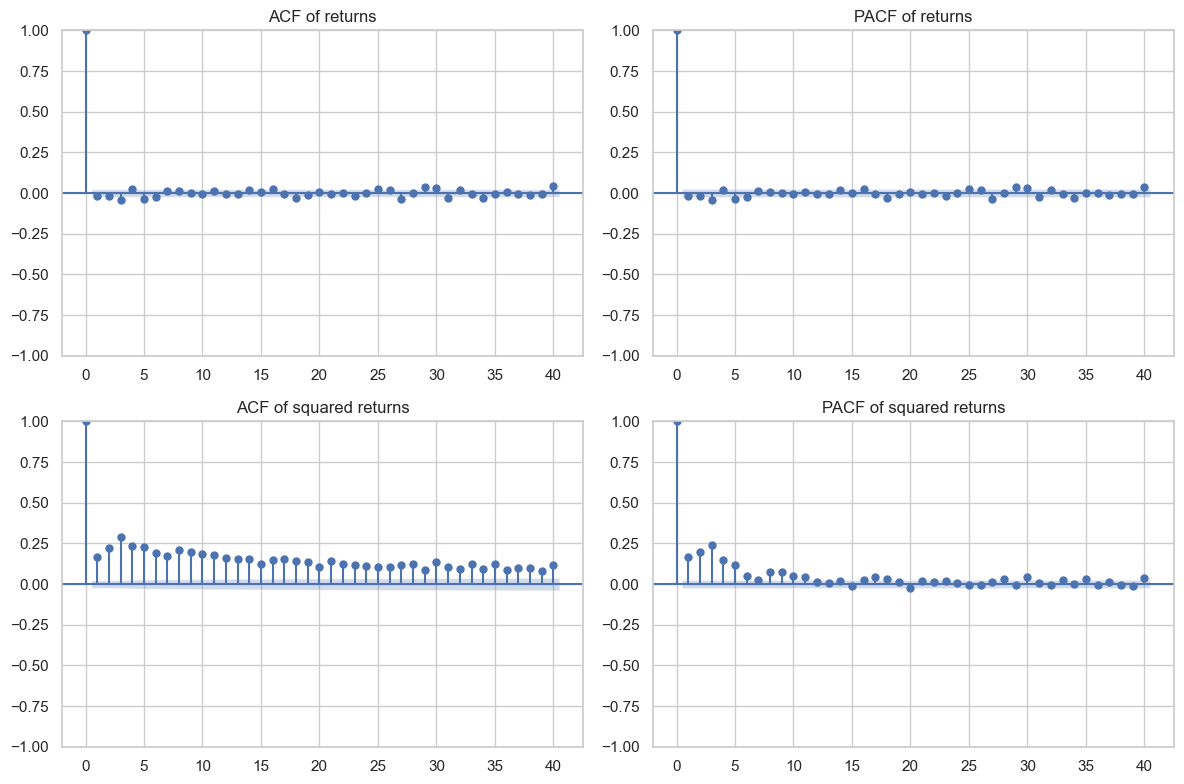

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ACF/PACF of raw returns (check for serial correlation in levels)
plot_acf(r, ax=axes[0, 0], lags=40)
axes[0, 0].set_title("ACF of returns")
plot_pacf(r, ax=axes[0, 1], lags=40, method='ywm')
axes[0, 1].set_title("PACF of returns")

# ACF/PACF of squared returns (proxy for volatility clustering)
r2 = r**2
plot_acf(r2, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("ACF of squared returns")
plot_pacf(r2, ax=axes[1, 1], lags=40, method='ywm')
axes[1, 1].set_title("PACF of squared returns")

plt.tight_layout()

# ARCH-LM tests at a few lags (on percent returns for stability)
print("\nARCH-LM tests for conditional heteroskedasticity:")
for lag in [5, 10, 20]:
    stat, pval, _, _ = het_arch(r * 100, nlags=lag)
    print(f" Lag {lag:2d}: LM stat = {stat:.2f}, p-value = {pval:.4e}")

### 2.3. Tail Analysis (QQ-Plots)

Compares the return distribution against Normal and Student-t distributions to visually demonstrate the presence of heavy tails.

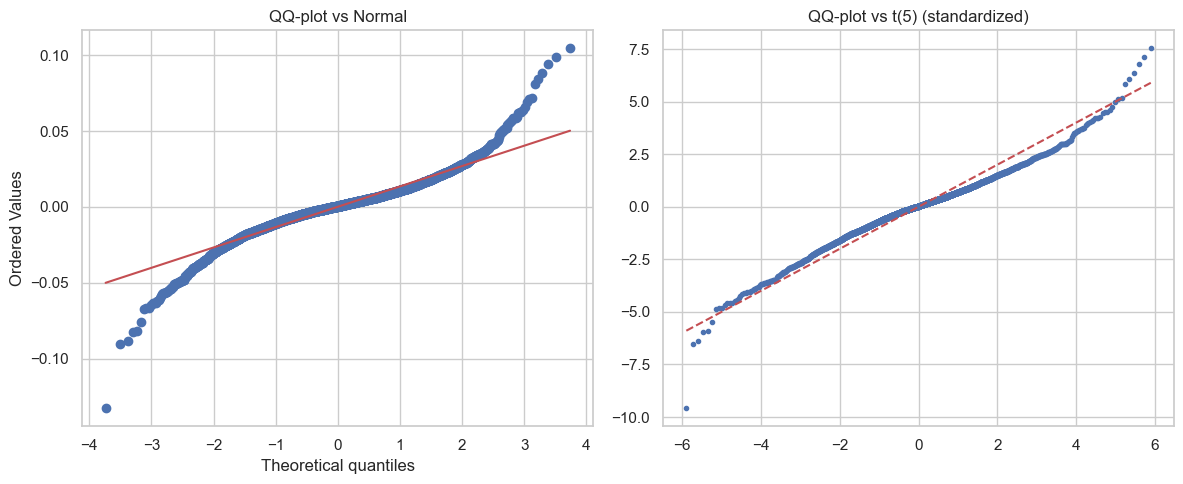

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# QQ against Normal (unconditional heavy tails)
stats.probplot(r, dist="norm", plot=ax[0])
ax[0].set_title("QQ-plot vs Normal")

# QQ against standardized t-distribution with dof = 5 (illustrative check for fat tails)
df_t = 5
t_dist = stats.t(df=df_t)
sorted_r = np.sort((r - r.mean()) / r.std(ddof=1))
theoretical_q = t_dist.ppf(np.linspace(0.001, 0.999, len(sorted_r)))

ax[1].plot(theoretical_q, sorted_r, marker='.', linestyle='none')
ax[1].plot(theoretical_q, theoretical_q, 'r--')
ax[1].set_title(f"QQ-plot vs t({df_t}) (standardized)")

plt.tight_layout()

### 2.4 Asymmetry & Leverage Effects (Engle–Ng Sign/Size Bias Diagnostics)

Engle & Ng (1993) diagnostics using standardized residuals from an initial symmetric GARCH model.

In [7]:
# Prepare returns series
r_clean = pd.Series(r).dropna().copy()

# arch is better with percent-scaled returns
r_for_arch = 100.0 * r_clean

# Fit an initial symmetric GARCH(1,1) (baseline) and get standardized residuals
try:
    from arch import arch_model
except ImportError as e:
    raise ImportError(
        "This cell requires the 'arch' package (arch_model). "
        "Install via: pip install arch"
    ) from e

# Symmetric GARCH: no leverage term; this is the intended baseline for Engle–Ng diagnostics
garch = arch_model(
    r_for_arch,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"  
)

garch_res = garch.fit(disp="off")

# Standardized residuals z_t = eps_t / sigma_t
eps = garch_res.resid
sigma = garch_res.conditional_volatility
z = (eps / sigma).dropna()

# Engle–Ng regressors (lagged sign + size components
# Dependent variable is current squared standardized residual
y = (z ** 2).iloc[1:] 

z_lag = z.shift(1).iloc[1:]  # z_{t-1} aligned with y
I_neg = (z_lag < 0).astype(int)  # sign-bias dummy

# Size components (Engle–Ng split)
neg_size = I_neg * z_lag                 # z_{t-1} on negative days (<=0)
pos_size = (1 - I_neg) * z_lag           # z_{t-1} on non-negative days (>0)

X = pd.DataFrame(
    {
        "const": 1.0,
        "I_neg": I_neg,         # sign bias
        "neg_size": neg_size,   # negative size bias
        "pos_size": pos_size,   # positive size bias
    },
    index=y.index
)

# OLS and test joint significance of bias terms
model = sm.OLS(y, X, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model.summary().tables[1])

# Joint test: no sign/size bias (all three terms jointly zero)
f_test = model.f_test("I_neg = 0, neg_size = 0, pos_size = 0")
print("\nJoint F-test (no sign/size bias):")
print(f"F-stat: {float(f_test.fvalue):.2f}, p-value: {float(f_test.pvalue):.4e}")

engle_ng_F = float(f_test.fvalue)
engle_ng_p = float(f_test.pvalue)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0421      0.044     23.516      0.000       0.955       1.129
I_neg          0.0532      0.065      0.819      0.413      -0.074       0.181
neg_size      -0.0540      0.047     -1.158      0.247      -0.145       0.037
pos_size      -0.2542      0.037     -6.855      0.000      -0.327      -0.182

Joint F-test (no sign/size bias):
F-stat: 35.11, p-value: 1.6031e-22


## Part 3: Feature Engineering & Baseline Models

### 3.1. The Feature Engine: EGARCH(1,1)–Skew-t

Fits the EGARCH model on the pre-test data to extract conditional volatility ($\sigma_t$). This creates the primary input feature x_sigma_t (standardized log-volatility) used by the downstream LQR and DQN models.

In [8]:
# Returns in percent for EGARCH estimation (numerical stability)
r_pct = 100.0 * r
r_pretest_pct = r_pct.loc[mask_pretest]

# EGARCH(1,1)-skew-t specification
egarch_spec = dict(
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
    dist="skewt",
    rescale=False,
)

# Fit EGARCH on pre-test period
am_pre = arch_model(r_pretest_pct, **egarch_spec)
res_pre = am_pre.fit(disp="off")

print(res_pre.summary().tables[0])

# Filter full sample with fixed parameters to extract latent volatility
am_full = arch_model(r_pct, **egarch_spec)
res_full = am_full.fix(res_pre.params)

# Extract conditional volatility and convert back to original scale
sigma_full_pct = res_full.conditional_volatility
sigma_full = sigma_full_pct / 100.0

# Build feature DataFrame
features = pd.DataFrame(index=r.index)
features["r"] = r
features["sigma"] = sigma_full

# Standardize log-volatility using pre-test statistics (prevents look-ahead bias)
log_sigma = np.log(features["sigma"])

mean_log_sigma_pre = log_sigma.loc[mask_pretest].mean()
std_log_sigma_pre  = log_sigma.loc[mask_pretest].std(ddof=1)

features["x_sigma_t"] = (log_sigma - mean_log_sigma_pre) / std_log_sigma_pre

# Store artifacts for later use (e.g., in RL environment)
ARTIFACTS = {
    "egarch_params": res_pre.params,
    "log_sigma_mean_pretest": mean_log_sigma_pre,
    "log_sigma_std_pretest": std_log_sigma_pre,
    "TRAIN_START": TRAIN_START,
    "VAL_START": VAL_START,
    "PRETEST_END": PRETEST_END,
    "TEST_START": TEST_START,
    "TEST_END": TEST_END,
}

features.head()

                           Constant Mean - EGARCH Model Results                          
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                EGARCH   Log-Likelihood:               -8248.04
Distribution:      Standardized Skew Student's t   AIC:                           16510.1
Method:                       Maximum Likelihood   BIC:                           16555.9
                                                   No. Observations:                 5138
Date:                           Fri, Dec 19 2025   Df Residuals:                     5137
Time:                                   16:32:56   Df Model:                            1


,r,sigma,x_sigma_t
date,,,
1996-01-02,0.012478,0.007248,-1.262268
1996-01-03,0.011392,0.007116,-1.306825
1996-01-04,-0.005742,0.006975,-1.355558
1996-01-05,-0.004786,0.007436,-1.199831
1996-01-08,-0.000976,0.007733,-1.104498


### 3.2. Baseline: Semi-Parametric VaR (Analytical)

Computes a semi-parametric Value-at-Risk (VaR) baseline by combining the EGARCH conditional volatility with empirical quantiles of standardized residuals, serving as a traditional econometric benchmark.

In [9]:
# Alpha levels and labels used consistently throughout the notebook
ALPHAS = [0.01, 0.025, 0.05]
ALPHA_LABELS = {0.01: "1", 0.025: "2p5", 0.05: "5"}

# Extract parameters from the pre-test EGARCH fit
mu_pct = res_pre.params["mu"]
mu_unit = mu_pct / 100.0

# Calculate standardized residuals (z) on the pre-test period
resids_pre_pct = res_pre.resid
sigma_pre_pct  = res_pre.conditional_volatility
z_pre = resids_pre_pct / sigma_pre_pct

# Empirical quantiles of innovations (pre-test only)
# Empirical quantiles rather than theoretical ones to capture any remaining non-normality
q_alpha = {a: z_pre.quantile(a) for a in ALPHAS}

print("Empirical quantiles of standardized residuals (pre-test):")
for a in ALPHAS:
    print(f" alpha={a:.3f}: q_alpha={q_alpha[a]: .4f}")


# Compute semi-parametric VaR for the full sample
# VaR = mean + sigma * quantile
for a in ALPHAS:
    label = ALPHA_LABELS[a]
    col_name = f"var_param_{label}"
    features[col_name] = mu_unit + features["sigma"] * q_alpha[a]

features[[c for c in features.columns if c.startswith("var_param_")]].head()

Empirical quantiles of standardized residuals (pre-test):
 alpha=0.010: q_alpha=-2.5730
 alpha=0.025: q_alpha=-2.0768
 alpha=0.050: q_alpha=-1.7148


,var_param_1,var_param_2p5,var_param_5
date,,,
1996-01-02,-0.018483,-0.014886,-0.012263
1996-01-03,-0.018144,-0.014613,-0.012037
1996-01-04,-0.017781,-0.014319,-0.011795
1996-01-05,-0.018968,-0.015277,-0.012586
1996-01-08,-0.019732,-0.015895,-0.013096


### 3.3. Linear Quantile Regression (LQR)

Fits a linear quantile regression model using the standardized volatility feature (x_sigma_t) to predict VaR, serving as a linear benchmark against the neural network.

In [10]:
# Mapping from alpha to column names
alpha_to_col_lqr = {a: f"var_lqr_{ALPHA_LABELS[a]}" for a in ALPHAS}

# Feature matrix: 1D standardized log-volatility + constant
X_all = features[["x_sigma_t"]].copy()
X_all_const = sm.add_constant(X_all, has_constant="add")

# Pre-test data (train + val) for estimation
X_pre = X_all_const.loc[mask_pretest]
y_pre = features.loc[mask_pretest, "r"]

for a in ALPHAS:
    col = alpha_to_col_lqr[a]
    print(f" - alpha = {a:.3f}, column = {col}")

    model = sm.QuantReg(y_pre.values, X_pre.values)
    res_q = model.fit(q=a)

    # Predict for full sample using the fitted coefficients
    q_hat_full = X_all_const.values @ res_q.params
    features[col] = q_hat_full.astype(float)

print([alpha_to_col_lqr[a] for a in ALPHAS])

 - alpha = 0.010, column = var_lqr_1
 - alpha = 0.025, column = var_lqr_2p5
 - alpha = 0.050, column = var_lqr_5
['var_lqr_1', 'var_lqr_2p5', 'var_lqr_5']


## Part 4: Deep Learning Implementation

### 4.1. Deep Quantile Network (DQN): Architecture & CV Setup

Defines the Neural Network class (MLP) and sets up the Time-Series Cross-Validation (TSCV) logic to respect the temporal order of financial data during training.

In [11]:
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# DQN output column mapping
alpha_to_col_dqn = {a: f"var_dqn_{ALPHA_LABELS[a]}" for a in ALPHAS}

# Prepare data for DQN
X_pre = features.loc[mask_pretest, ["x_sigma_t"]].values.astype(np.float32)
y_pre = features.loc[mask_pretest, "r"].values.astype(np.float32)

X_full = features[["x_sigma_t"]].values.astype(np.float32)

pre_dates = features.index[mask_pretest]
n_pre = len(pre_dates)
if n_pre < 50:
    raise ValueError("Pre-test sample too short for time-series cross-validation.")

# Expanding-window CV folds
N_FOLDS = 4
indices = np.arange(n_pre)
segments = np.array_split(indices, N_FOLDS + 1)

cv_folds = []
print("Time-series CV folds for DQN on pre-test period:")
for k in range(1, len(segments)):
    train_idx = np.concatenate(segments[:k])
    val_idx = segments[k]
    cv_folds.append((train_idx, val_idx))

    print(
        f"Fold {k}: "
        f"train[{pre_dates[train_idx[0]].date()} -> {pre_dates[train_idx[-1]].date()}], "
        f"val[{pre_dates[val_idx[0]].date()} -> {pre_dates[val_idx[-1]].date()}], "
        f"n_train={len(train_idx)}, n_val={len(val_idx)}"
    )

# Global training constants
BATCH_SIZE = 256

# Final training DataLoader on the full pre-test sample
pre_dataset = TensorDataset(
    torch.from_numpy(X_pre),
    torch.from_numpy(y_pre).view(-1, 1),
)
pre_loader = DataLoader(pre_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Model definition
class DQN(nn.Module):
    def __init__(self, input_dim: int = 1, hidden_dim: int = 64, n_layers: int = 2):
        super().__init__()
        layers = []
        last_dim = input_dim

        for _ in range(n_layers):
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(nn.ReLU())
            last_dim = hidden_dim

        layers.append(nn.Linear(last_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Losses
def pinball_loss_torch(y_true: torch.Tensor, y_pred: torch.Tensor, alpha: float) -> torch.Tensor:
    diff = y_true - y_pred
    loss = torch.where(diff < 0.0, (alpha - 1.0) * diff, alpha * diff)
    return loss.mean()

def monotonicity_penalty(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    # Ensure x tracks gradients
    x_req = x.detach().clone().requires_grad_(True)
    y = model(x_req)
    grad = torch.autograd.grad(outputs=y.sum(), inputs=x_req, create_graph=True)[0]
    return torch.relu(grad).mean()  # penalize positive slope only

Time-series CV folds for DQN on pre-test period:
Fold 1: train[1996-01-02 -> 1999-12-23], val[1999-12-24 -> 2004-01-02], n_train=1028, n_val=1028
Fold 2: train[1996-01-02 -> 2004-01-02], val[2004-01-05 -> 2008-01-02], n_train=2056, n_val=1028
Fold 3: train[1996-01-02 -> 2008-01-02], val[2008-01-03 -> 2011-12-29], n_train=3084, n_val=1027
Fold 4: train[1996-01-02 -> 2011-12-29], val[2011-12-30 -> 2015-12-31], n_train=4111, n_val=1027


### 4.2. Training the DQN

Executes the hyperparameter search (layers, learning rate) and trains the final DQN models for all alpha levels (1%, 2.5%, 5%).

Training uses pinball + a fixed monotonicity penalty; architecture selection and early stopping use unpenalized pinball loss.

In [12]:
def train_dqn_for_alpha(
    alpha: float,
    arch_grid=None,
    lr_candidates=None,
    max_epochs: int = 200,
    patience: int = 20,
    weight_decay: float = 1e-4,
    lambda_mono: float = 0.10,
    grad_clip_norm: float = 1.0,
):
    """
    Two-stage training for a given quantile level alpha using expanding-window CV
    on the pre-test period, then final training on the full pre-test sample.

    Regularization:
      - Adam weight decay (L2): reduces high-variance function fits
      - Monotonicity penalty: discourages d(VaR)/dx > 0 (economically implausible)
    """
    if arch_grid is None:
        arch_grid = [
            {"hidden_dim": 32, "n_layers": 1},
            {"hidden_dim": 64, "n_layers": 1},
            {"hidden_dim": 32, "n_layers": 2},
            {"hidden_dim": 64, "n_layers": 2},
        ]
    if lr_candidates is None:
        lr_candidates = [1e-3, 3e-4, 1e-4]

    # Full pre-test tensors on device for efficient indexing during CV
    X_pre_t = torch.from_numpy(X_pre).to(device)
    y_pre_t = torch.from_numpy(y_pre).view(-1, 1).to(device)

    best_cfg = None
    best_lr = None
    best_epochs = None
    best_val_loss = np.inf

    # Hyperparameter search via TS-CV
    for cfg in arch_grid:
        for lr in lr_candidates:
            fold_losses = []
            fold_epochs = []

            for (train_idx, val_idx) in cv_folds:
                X_train = X_pre_t[train_idx]
                y_train = y_pre_t[train_idx]
                X_val = X_pre_t[val_idx]
                y_val = y_pre_t[val_idx]

                train_ds = TensorDataset(X_train, y_train)
                train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

                model = DQN(
                    input_dim=1,
                    hidden_dim=cfg["hidden_dim"],
                    n_layers=cfg["n_layers"],
                ).to(device)

                optimizer = torch.optim.Adam(
                    model.parameters(),
                    lr=lr,
                    weight_decay=weight_decay,
                )

                best_val_for_fold = np.inf
                best_epoch_for_fold = 0
                no_improve = 0

                for epoch in range(1, max_epochs + 1):
                    model.train()
                    for xb, yb in train_loader:
                        xb = xb.to(device)
                        yb = yb.to(device)

                        optimizer.zero_grad(set_to_none=True)
                        preds = model(xb)

                        loss_q = pinball_loss_torch(yb, preds, alpha)

                        # Monotonicity penalty
                        if lambda_mono and lambda_mono > 0.0:
                            mono_pen = monotonicity_penalty(model, xb)
                            loss = loss_q + lambda_mono * mono_pen
                        else:
                            loss = loss_q

                        loss.backward()
                        if grad_clip_norm and grad_clip_norm > 0.0:
                            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
                        optimizer.step()

                    # Validation
                    model.eval()
                    with torch.no_grad():
                        preds_val = model(X_val)
                        val_loss = pinball_loss_torch(y_val, preds_val, alpha).item()

                    # Early stopping tracking (on pure pinball loss)
                    if val_loss < best_val_for_fold - 1e-6:
                        best_val_for_fold = val_loss
                        best_epoch_for_fold = epoch
                        no_improve = 0
                    else:
                        no_improve += 1
                        if no_improve >= patience:
                            break

                fold_losses.append(best_val_for_fold)
                fold_epochs.append(best_epoch_for_fold)

            mean_val_loss = float(np.mean(fold_losses))
            mean_epochs = int(max(1, round(float(np.mean(fold_epochs)))))

            if mean_val_loss < best_val_loss:
                best_val_loss = mean_val_loss
                best_cfg = cfg
                best_lr = lr
                best_epochs = mean_epochs

    print(
        f"Selected for alpha={alpha:.3f}: "
        f"arch={best_cfg}, lr={best_lr}, epochs={best_epochs}, "
        f"cv_pinball={best_val_loss:.6f}, "
        f"weight_decay={weight_decay}, lambda_mono={lambda_mono}"
    )

    # Final training on full pre-test
    model_final = DQN(
        input_dim=1,
        hidden_dim=best_cfg["hidden_dim"],
        n_layers=best_cfg["n_layers"],
    ).to(device)

    optimizer_final = torch.optim.Adam(
        model_final.parameters(),
        lr=best_lr,
        weight_decay=weight_decay,
    )

    model_final.train()
    for epoch in range(1, best_epochs + 1):
        for xb, yb in pre_loader:
            xb = xb.to(device)
            yb = yb.view(-1, 1).to(device)

            optimizer_final.zero_grad(set_to_none=True)
            preds = model_final(xb)

            loss_q = pinball_loss_torch(yb, preds, alpha)

            if lambda_mono and lambda_mono > 0.0:
                mono_pen = monotonicity_penalty(model_final, xb)
                loss = loss_q + lambda_mono * mono_pen
            else:
                loss = loss_q

            loss.backward()
            if grad_clip_norm and grad_clip_norm > 0.0:
                torch.nn.utils.clip_grad_norm_(model_final.parameters(), max_norm=grad_clip_norm)
            optimizer_final.step()

    return model_final

# Train DQN for each alpha and generate full-sample VaR forecasts
df_dqn = pd.DataFrame(index=features.index)
X_full_t = torch.from_numpy(X_full).to(device)

for a in ALPHAS:
    col = alpha_to_col_dqn[a]
    print(f"Training DQN with time-series CV for alpha = {a:.3f} ...")
    model_a = train_dqn_for_alpha(
        alpha=a,
        weight_decay=1e-4,
        lambda_mono=0.10,
        grad_clip_norm=1.0,
    )
    model_a.eval()
    with torch.no_grad():
        preds_full = model_a(X_full_t).detach().cpu().numpy().ravel()
    df_dqn[col] = preds_full.astype(float)

Training DQN with time-series CV for alpha = 0.010 ...
Selected for alpha=0.010: arch={'hidden_dim': 64, 'n_layers': 2}, lr=0.0003, epochs=56, cv_pinball=0.000405, weight_decay=0.0001, lambda_mono=0.1
Training DQN with time-series CV for alpha = 0.025 ...
Selected for alpha=0.025: arch={'hidden_dim': 64, 'n_layers': 2}, lr=0.001, epochs=40, cv_pinball=0.000870, weight_decay=0.0001, lambda_mono=0.1
Training DQN with time-series CV for alpha = 0.050 ...
Selected for alpha=0.050: arch={'hidden_dim': 64, 'n_layers': 2}, lr=0.001, epochs=32, cv_pinball=0.001510, weight_decay=0.0001, lambda_mono=0.1


### 4.3. Post-Processing: Non-Crossing Constraint

Applies a logical constraint to ensure that VaR at 1% is always more extreme than VaR at 5% (monotonicity) to prevent illogical quantile crossing.

In [13]:
def enforce_non_crossing(df_q: pd.DataFrame, alpha_list: list) -> pd.DataFrame:
    df_sorted = df_q.copy()

    # Identify columns sorted by alpha (ascending risk)
    sorted_alphas = sorted(alpha_list)
    cols_sorted = [f"var_dqn_{ALPHA_LABELS[a]}" for a in sorted_alphas]

    # Apply Rearrangement: Sort every row (axis=1) from smallest (most negative) to largest
    arr = df_sorted[cols_sorted].values
    arr_nc = np.sort(arr, axis=1)

    df_sorted[cols_sorted] = arr_nc
    return df_sorted

# Apply the correction
df_dqn_nc = enforce_non_crossing(df_dqn, ALPHAS)

# Write corrected VaR back into `features` for backtesting
for a in ALPHAS:
    col = alpha_to_col_dqn[a]
    features[col] = df_dqn_nc[col].values

print("DQN VaR columns updated in 'features':")
print([alpha_to_col_dqn[a] for a in ALPHAS])

DQN VaR columns updated in 'features':
['var_dqn_1', 'var_dqn_2p5', 'var_dqn_5']


## Part 5: Statistical Backtesting & Performance

### 5.1. Backtesting Utilities

Defines the helper functions for standard VaR tests: Kupiec (LRuc), Christoffersen (LRcc), Dynamic Quantile (DQ), and the Pinball Loss function.

In [14]:
def pinball_loss(y, q, alpha: float) -> float:
    y = np.asarray(y)
    q = np.asarray(q)
    diff = y - q
    return np.mean(np.where(diff < 0.0, (alpha - 1.0) * diff, alpha * diff))

def backtest_var(y, q, alpha: float, dq_lags: int = 4) -> dict:
    y = np.asarray(y)
    q = np.asarray(q)
    T = len(y)
    I = (y < q).astype(int)  # Hit sequence (1 if violation, 0 otherwise)
    n_exc = I.sum()
    hit_rate = n_exc / T

    # 1. Kupiec Test (Unconditional Coverage - LRuc)
    if 0 < n_exc < T:
        pi_hat = hit_rate
        logL0 = n_exc * np.log(alpha) + (T - n_exc) * np.log(1.0 - alpha)
        logL1 = n_exc * np.log(pi_hat) + (T - n_exc) * np.log(1.0 - pi_hat)
        LRuc = -2.0 * (logL0 - logL1)
        p_LRuc = 1.0 - chi2.cdf(LRuc, df=1)
    else:
        LRuc = np.nan
        p_LRuc = np.nan

    # 2. Christoffersen Test (Independence - LRind & Conditional Coverage - LRcc)
    I_lag = I[:-1]
    I_cur = I[1:]

    # Transition counts
    N00 = ((I_lag == 0) & (I_cur == 0)).sum()
    N01 = ((I_lag == 0) & (I_cur == 1)).sum()
    N10 = ((I_lag == 1) & (I_cur == 0)).sum()
    N11 = ((I_lag == 1) & (I_cur == 1)).sum()
    N0 = N00 + N01
    N1 = N10 + N11

    if N0 > 0 and N1 > 0:
        pi01 = N01 / N0
        pi11 = N11 / N1
        pi = (N01 + N11) / (N0 + N1)

        # Log-likelihood under independence (Null)
        logL_indep = 0.0
        if N00 > 0: logL_indep += N00 * np.log(1.0 - pi)
        if N01 > 0: logL_indep += N01 * np.log(pi)
        if N10 > 0: logL_indep += N10 * np.log(1.0 - pi)
        if N11 > 0: logL_indep += N11 * np.log(pi)

        # Log-likelihood under Markov dependence (Alt)
        logL_markov = 0.0
        if N00 > 0: logL_markov += N00 * np.log(1.0 - pi01)
        if N01 > 0: logL_markov += N01 * np.log(pi01)
        if N10 > 0: logL_markov += N10 * np.log(1.0 - pi11)
        if N11 > 0: logL_markov += N11 * np.log(pi11)

        LRind = -2.0 * (logL_indep - logL_markov)
        p_LRind = 1.0 - chi2.cdf(LRind, df=1)

        if not np.isnan(LRuc):
            LRcc = LRuc + LRind
            p_LRcc = 1.0 - chi2.cdf(LRcc, df=2)
        else:
            LRcc = np.nan
            p_LRcc = np.nan
    else:
        LRind = np.nan
        p_LRind = np.nan
        LRcc = np.nan
        p_LRcc = np.nan

    # 3. Dynamic Quantile (DQ) Test (Engle & Manganelli)
    if dq_lags > 0 and T > dq_lags + 1:
        # Dependent variable: De-meaned violations
        Y_dq = I[dq_lags:] - alpha
        
        # Design matrix: Constant + Lags of violations + Current VaR forecast
        X_list = [np.ones(len(Y_dq))] 
        for lag in range(1, dq_lags + 1):
            X_list.append(I[dq_lags - lag : -lag])
        
        # Align VaR forecast q with Y_dq (starts at index dq_lags)
        X_list.append(q[dq_lags:])
        
        X = np.column_stack(X_list)

        # Fit OLS to check joint significance
        dq_model = sm.OLS(Y_dq, X).fit()
        dq_stat = len(Y_dq) * dq_model.rsquared
        p_dq = 1.0 - chi2.cdf(dq_stat, df=X.shape[1])
    else:
        dq_stat = np.nan
        p_dq = np.nan

    # 4. Confidence Interval for Hit Rate (Clopper-Pearson)
    ci_low, ci_high = binom.interval(0.95, T, alpha)
    ci_low /= T
    ci_high /= T

    pl = pinball_loss(y, q, alpha)

    return {
        "alpha": alpha,
        "n": T,
        "violations": int(n_exc),
        "hit_rate": hit_rate,
        "ci_low_95": ci_low,
        "ci_high_95": ci_high,
        "LRuc": LRuc,
        "p_LRuc": p_LRuc,
        "LRcc": LRcc,
        "p_LRcc": p_LRcc,
        "DQ": dq_stat,
        "p_DQ": p_dq,
        "pinball": pl,
    }

### 5.2. Running Backtests (All Models)

Executes the backtests on the out-of-sample Test set for Semi-Parametric, LQR, and DQN models, aggregating Hit Rates and p-values.

In [15]:
def run_backtests(alpha_to_col_map: dict, model_name: str) -> pd.DataFrame:
    records = []
    for a in ALPHAS:
        label = ALPHA_LABELS[a]
        col = alpha_to_col_map[a]

        # Extract Test set (out-of-sample)
        y_test = features.loc[mask_test, "r"]
        q_test = features.loc[mask_test, col]

        # Run statistical tests
        result = backtest_var(y_test, q_test, alpha=a, dq_lags=4)
        result["model"] = model_name
        result["alpha_label"] = label
        records.append(result)

    return (
        pd.DataFrame(records)
        .set_index(["model", "alpha_label"])
        .sort_index()
    )

# 1. Semi-Parametric Backtest (Benchmark)
# Create mapping for semi-parametric columns on the fly
alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}
bt_parametric = run_backtests(alpha_to_col_param, "Semi-Parametric EGARCH-skewt")

# 2. Linear Quantile Regression (LQR)
bt_lqr = run_backtests(alpha_to_col_lqr, "LQR")

# 3. Deep Quantile Network (DQN)
bt_dqn = run_backtests(alpha_to_col_dqn, "DQN")

print(bt_parametric)
print(bt_lqr)
print(bt_dqn)

                                          alpha     n  violations  hit_rate  \
model                        alpha_label                                      
Semi-Parametric EGARCH-skewt 1            0.010  2311          27  0.011683   
                             2p5          0.025  2311          59  0.025530   
                             5            0.050  2311          96  0.041540   

                                          ci_low_95  ci_high_95      LRuc  \
model                        alpha_label                                    
Semi-Parametric EGARCH-skewt 1             0.006058    0.014280  0.627476   
                             2p5           0.019039    0.031588  0.026458   
                             5             0.041108    0.058849  3.685386   

                                            p_LRuc      LRcc    p_LRcc  \
model                        alpha_label                                 
Semi-Parametric EGARCH-skewt 1            0.428283  1.266124  0.530964

### 5.3. Comparative Loss Analysis

Aggregates the Pinball Loss (error metric) for all three models to identify which method minimizes the quantile loss function best.

In [16]:
rows = []

for a in ALPHAS:
    label = ALPHA_LABELS[a]
    
    # Extract Pinball Loss for each model at this alpha level
    pl_param = bt_parametric.loc[("Semi-Parametric EGARCH-skewt", label), "pinball"]
    pl_lqr   = bt_lqr.loc[("LQR", label), "pinball"]
    pl_dqn   = bt_dqn.loc[("DQN", label), "pinball"]
    
    rows.append({
        "alpha": a,
        "alpha_label": label,
        "Pinball_Semi-Parametric": pl_param,
        "Pinball_LQR": pl_lqr,
        "Pinball_DQN": pl_dqn
    })

df_pinball_cmp = (
    pd.DataFrame(rows)
    .set_index("alpha_label")
    .sort_index()
)

print(df_pinball_cmp)

             alpha  Pinball_Semi-Parametric  Pinball_LQR  Pinball_DQN
alpha_label                                                          
1            0.010                 0.000412     0.000425     0.000428
2p5          0.025                 0.000789     0.000818     0.000786
5            0.050                 0.001281     0.001324     0.001296


### 5.4. Diebold-Mariano Significance Tests

Performs pairwise statistical tests on the Pinball Loss series to determine if the DQN's performance improvement is statistically significant compared to the baselines.

In [25]:
# Ensure the semi-parametric column mapping is available
alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}

def pinball_loss_series(y, q, alpha: float) -> np.ndarray:
    y = np.asarray(y)
    q = np.asarray(q)
    diff = y - q
    return np.where(diff < 0.0, (alpha - 1.0) * diff, alpha * diff)

def dm_test(loss1, loss2, max_lag: int = 4):
    d = np.asarray(loss1) - np.asarray(loss2)
    T = len(d)
    d_bar = d.mean()

    # Newey-West variance estimate
    gamma0 = np.var(d, ddof=1)
    var_hat = gamma0

    for lag in range(1, max_lag + 1):
        w = 1.0 - lag / (max_lag + 1.0)
        # sample autocovariance at lag
        cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        var_hat += 2.0 * w * cov

    var_hat = max(var_hat, 1e-12)
    dm_stat = d_bar / np.sqrt(var_hat / T)
    
    # Two-sided p-value
    p_two = 2.0 * (1.0 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_two

y_test = features.loc[mask_test, "r"]
dm_records = []


for a in ALPHAS:
    label = ALPHA_LABELS[a]

    # Retrieve forecasts for this alpha
    q_param = features.loc[mask_test, alpha_to_col_param[a]]
    q_lqr   = features.loc[mask_test, alpha_to_col_lqr[a]]
    q_dqn   = features.loc[mask_test, alpha_to_col_dqn[a]]

    # Compute loss series
    L_param = pinball_loss_series(y_test, q_param, a)
    L_lqr   = pinball_loss_series(y_test, q_lqr,   a)
    L_dqn   = pinball_loss_series(y_test, q_dqn,   a)

    # 1. Semi-Parametric vs LQR
    stat_pl, p_pl = dm_test(L_param, L_lqr, max_lag=4)
    dm_records.append({
        "alpha_label": label,
        "alpha": a,
        "comparison": "Semi-Parametric - LQR",
        "DM_stat": stat_pl,
        "p_value": p_pl,
    })

    # 2. Semi-Parametric vs DQN
    stat_pd, p_pd = dm_test(L_param, L_dqn, max_lag=4)
    dm_records.append({
        "alpha_label": label,
        "alpha": a,
        "comparison": "Semi-Parametric - DQN",
        "DM_stat": stat_pd,
        "p_value": p_pd,
    })

    # 3. LQR vs DQN
    stat_ld, p_ld = dm_test(L_lqr, L_dqn, max_lag=4)
    dm_records.append({
        "alpha_label": label,
        "alpha": a,
        "comparison": "LQR - DQN",
        "DM_stat": stat_ld,
        "p_value": p_ld,
    })

dm_table = (
    pd.DataFrame(dm_records)
    .set_index(["alpha_label", "comparison"])
    .sort_index()
)

print(dm_table)

                                   alpha   DM_stat   p_value
alpha_label comparison                                      
1           LQR - DQN              0.010 -0.242742  0.808205
            Semi-Parametric - DQN  0.010 -1.705868  0.088033
            Semi-Parametric - LQR  0.010 -1.001329  0.316668
2p5         LQR - DQN              0.025  2.206206  0.027370
            Semi-Parametric - DQN  0.025  0.437890  0.661466
            Semi-Parametric - LQR  0.025 -2.654219  0.007949
5           LQR - DQN              0.050  2.381389  0.017247
            Semi-Parametric - DQN  0.050 -2.364288  0.018065
            Semi-Parametric - LQR  0.050 -3.742215  0.000182


### 5.5. Realized Shortfall (ES) Diagnostics

Calculates the average return of the violations (Expected Shortfall proxy) and tail severity metrics to see how the models behave when the VaR limit is breached.

In [18]:
def realized_shortfall(y, q):
    y = np.asarray(y)
    q = np.asarray(q)
    mask = y < q
    n_viol = int(mask.sum())
    
    if n_viol == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, n_viol

    viol = y[mask]
    rs = viol.mean()
    median_viol = np.median(viol)
    q10_viol = np.quantile(viol, 0.10)
    min_viol = viol.min()
    max_viol = viol.max()
    
    return rs, median_viol, q10_viol, min_viol, max_viol, n_viol

# Column maps for each model
alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}
alpha_to_col_lqr   = {a: f"var_lqr_{ALPHA_LABELS[a]}"   for a in ALPHAS}
alpha_to_col_dqn   = {a: f"var_dqn_{ALPHA_LABELS[a]}"   for a in ALPHAS}

records_es = []
y_test = features.loc[mask_test, "r"]

models_to_test = [
    ("Semi-Parametric EGARCH-skewt", alpha_to_col_param),
    ("LQR", alpha_to_col_lqr),
    ("DQN", alpha_to_col_dqn),
]


for model_name, col_map in models_to_test:
    for a in ALPHAS:
        label = ALPHA_LABELS[a]
        col_q = col_map[a]

        q_test = features.loc[mask_test, col_q]
        
        # Calculate ES and tail metrics
        rs, median_viol, q10_viol, min_viol, max_viol, n_viol = realized_shortfall(
            y_test, q_test
        )

        records_es.append({
            "model": model_name,
            "alpha_label": label,
            "alpha": a,
            "n_viol": n_viol,
            "RS": rs,
            "viol_median": median_viol,
            "viol_q10": q10_viol,
            "viol_min": min_viol,
            "viol_max": max_viol,
            "avg_VaR": q_test.mean(),
        })

es_summary = (
    pd.DataFrame(records_es)
    .set_index(["model", "alpha_label"])
    .sort_index()
)

print(es_summary)

                                          alpha  n_viol        RS  \
model                        alpha_label                            
DQN                          1            0.010      38 -0.032774   
                             2p5          0.025      68 -0.028220   
                             5            0.050      98 -0.024771   
LQR                          1            0.010      24 -0.038607   
                             2p5          0.025      60 -0.026959   
                             5            0.050     114 -0.023542   
Semi-Parametric EGARCH-skewt 1            0.010      27 -0.036880   
                             2p5          0.025      59 -0.029729   
                             5            0.050      96 -0.026561   

                                          viol_median  viol_q10  viol_min  \
model                        alpha_label                                    
DQN                          1              -0.026436 -0.047016 -0.132405   
         

## Part 6: Interpretability & Explainability

### 6.1. The "Money Plot": VaR vs. Volatility

Visualizes how aggressive the VaR forecasts are relative to the input volatility level for all three models. Overlays the "Money Plot" with histograms of specific market regimes (2020 Crisis, 2022 Inflation) to show where the model has abundant training data versus where it is extrapolating.

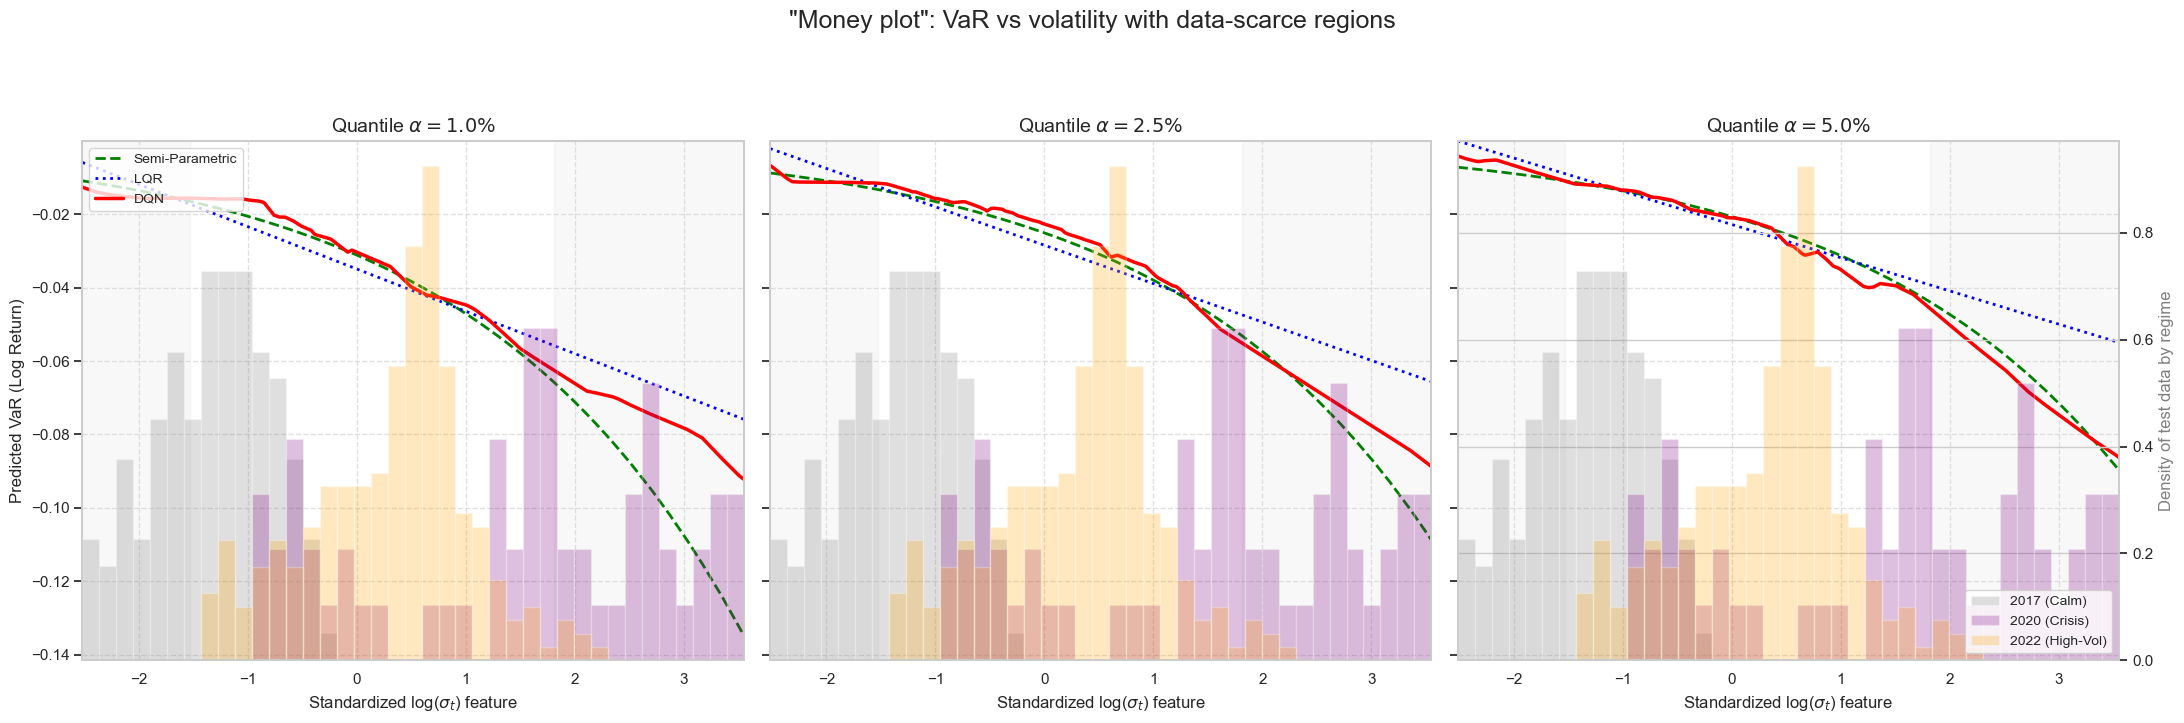

In [19]:
alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}
alpha_to_col_lqr   = {a: f"var_lqr_{ALPHA_LABELS[a]}"   for a in ALPHAS}
alpha_to_col_dqn   = {a: f"var_dqn_{ALPHA_LABELS[a]}"   for a in ALPHAS}

features_test = features.loc[mask_test].copy()
features_pretest = features.loc[mask_pretest].copy()

# global volatility quantiles on test set
q_low  = features_pretest["x_sigma_t"].quantile(0.05)
q_high = features_pretest["x_sigma_t"].quantile(0.95)
x_min  = features_test["x_sigma_t"].min()
x_max  = features_test["x_sigma_t"].max()

# regimes for the histograms (same as in your raw money plot)
REGIME_CALM      = features_test.loc["2017-01-01":"2017-12-31", "x_sigma_t"].dropna()
REGIME_CRISIS    = features_test.loc["2020-02-01":"2020-04-30", "x_sigma_t"].dropna()
REGIME_INFLATION = features_test.loc["2022-01-01":"2022-12-31", "x_sigma_t"].dropna()

regime_series = {
    "2017 (Calm)"    : REGIME_CALM,
    "2020 (Crisis)"  : REGIME_CRISIS,
    "2022 (High-Vol)": REGIME_INFLATION,
}
regime_colors = {
    "2017 (Calm)"    : "grey",
    "2020 (Crisis)"  : "purple",
    "2022 (High-Vol)": "orange",
}
bins_reg = np.linspace(x_min, x_max, 40)

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig.suptitle(
    '"Money plot": VaR vs volatility with data-scarce regions',
    fontsize=18,
    y=1.03,
)

global_y_min, global_y_max = np.inf, -np.inf

money_plot_smooth = {} 

for i, alpha in enumerate(ALPHAS):
    ax = axes[i]

    col_param = alpha_to_col_param[alpha]
    col_lqr   = alpha_to_col_lqr[alpha]
    col_dqn   = alpha_to_col_dqn[alpha]
    df_raw = features.loc[mask_test].copy().sort_values(by="x_sigma_t")
    
    money_plot_smooth[alpha] = df_raw

    x       = df_raw["x_sigma_t"].values
    v_param = df_raw[col_param].values
    v_lqr   = df_raw[col_lqr].values
    v_dqn   = df_raw[col_dqn].values

    local_min = min(v_param.min(), v_lqr.min(), v_dqn.min())
    local_max = max(v_param.max(), v_lqr.max(), v_dqn.max())
    global_y_min = min(global_y_min, local_min)
    global_y_max = max(global_y_max, local_max)

    # shade data-scarce regions 
    ax.axvspan(x_min, q_low,  color="lightgrey", alpha=0.15, label=None)
    ax.axvspan(q_high, x_max, color="lightgrey", alpha=0.15, label=None)

    # VaR curves
    ax.plot(x, v_param, label="Semi-Parametric",
            color="green", linestyle="--", linewidth=2)
    ax.plot(x, v_lqr,   label="LQR",
            color="blue", linestyle=":", linewidth=2)
    ax.plot(x, v_dqn,   label="DQN",
            color="red", linestyle="-", linewidth=2.5)

    ax.set_xlim(x_min, x_max)
    ax.set_title(fr"Quantile $\alpha = {alpha*100:.1f}\%$", fontsize=14)
    ax.set_xlabel(r"Standardized log($\sigma_t$) feature", fontsize=12)
    if i == 0:
        ax.set_ylabel("Predicted VaR (Log Return)", fontsize=12)

    ax.grid(True, linestyle="--", alpha=0.6)

    # regime histograms on second axis
    ax2 = ax.twinx()
    for name, series in regime_series.items():
        s = series.dropna().values
        if len(s) < 10:
            continue
        ax2.hist(
            s, bins=bins_reg, density=True,
            alpha=0.25, color=regime_colors[name], label=name,
        )

    ax2.set_ylim(bottom=0)
    if i == 2:
        ax2.set_ylabel("Density of test data by regime", fontsize=12, color="gray")
        ax2.legend(loc="lower right", fontsize=10)
    else:
        ax2.set_yticks([])
        ax2.set_ylabel("")

for ax in axes:
    ax.set_ylim(global_y_min * 1.05, global_y_max * 1.05)

axes[0].legend(loc="upper left", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 6.2. Local Sensitivity Analysis (Gradients)

Computes the gradient $\partial VaR / \partial \sigma$ to show how reactive the Neural Network is to changes in market volatility compared to the linear and semi-parametric baselines.

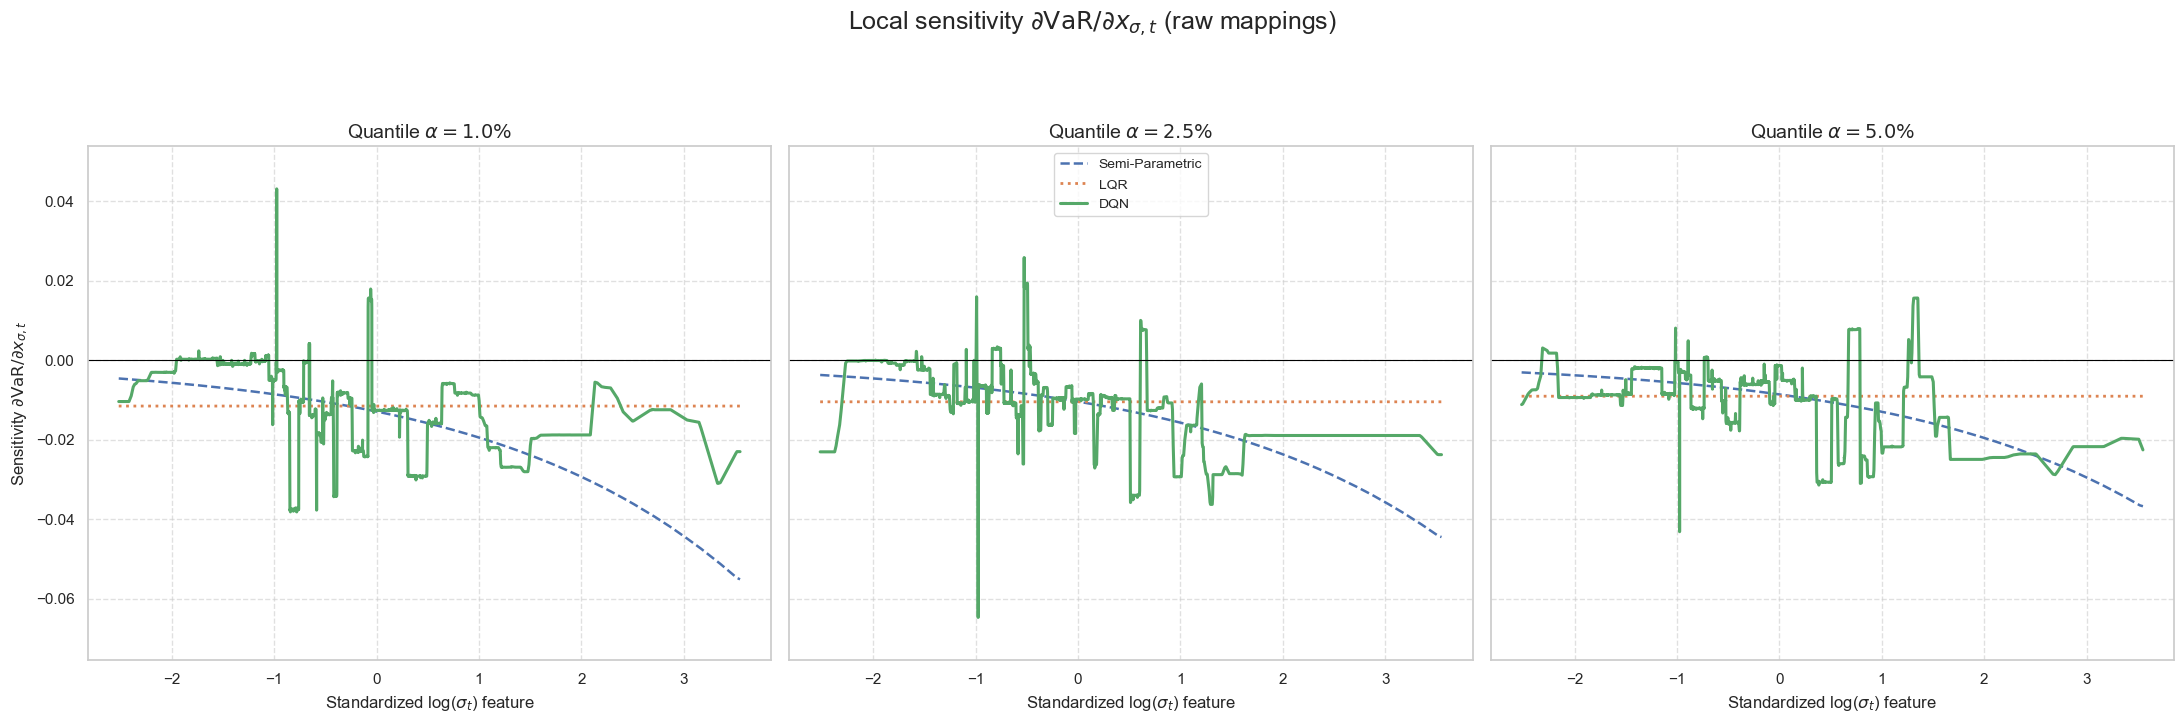

In [20]:
# ensure mappings exist (defensive)
alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}
alpha_to_col_lqr   = {a: f"var_lqr_{ALPHA_LABELS[a]}"   for a in ALPHAS}
alpha_to_col_dqn   = {a: f"var_dqn_{ALPHA_LABELS[a]}"   for a in ALPHAS}

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig.suptitle(
    r"Local sensitivity $\partial \mathrm{VaR} / \partial x_{\sigma,t}$ "
    "(raw mappings)",
    fontsize=18,
    y=1.03,
)

all_grads = []

for i, alpha in enumerate(ALPHAS):
    ax = axes[i]
    alpha_label = ALPHA_LABELS[alpha]

    col_param = alpha_to_col_param[alpha]
    col_lqr   = alpha_to_col_lqr[alpha]
    col_dqn   = alpha_to_col_dqn[alpha]

    # Retrieve raw VaR–volatility mapping from the money plot cell
    if "money_plot_smooth" not in globals() or alpha not in money_plot_smooth:
        raise RuntimeError(
            "money_plot_smooth is not available. Run the money-plot cell (10) first."
        )

    df_raw = money_plot_smooth[alpha]   # this is df_plot sorted by x_sigma_t

    x       = df_raw["x_sigma_t"].values
    v_param = df_raw[col_param].values
    v_lqr   = df_raw[col_lqr].values
    v_dqn   = df_raw[col_dqn].values

    # numerical gradients ∂VaR/∂x_sigma_t (no smoothing)
    g_param = np.gradient(v_param, x)
    g_lqr   = np.gradient(v_lqr,   x)
    g_dqn   = np.gradient(v_dqn,   x)

    all_grads.append(g_param)
    all_grads.append(g_lqr)
    all_grads.append(g_dqn)

    ax.plot(x, g_param, linestyle="--", linewidth=1.8,
            label="Semi-Parametric")
    ax.plot(x, g_lqr,   linestyle=":",  linewidth=2.0,
            label="LQR")
    ax.plot(x, g_dqn,   linestyle="-",  linewidth=2.2,
            label="DQN")

    ax.axhline(0.0, color="black", linewidth=0.8)

    ax.set_title(fr"Quantile $\alpha = {alpha*100:.1f}\%$", fontsize=14)
    ax.set_xlabel(r"Standardized log($\sigma_t$) feature", fontsize=12)
    if i == 0:
        ax.set_ylabel(
            r"Sensitivity $\partial \mathrm{VaR} / \partial x_{\sigma,t}$",
            fontsize=12,
        )

    ax.grid(True, linestyle="--", alpha=0.6)

# Common y-limits for all panels
all_grads = np.concatenate(all_grads)
gmin, gmax = all_grads.min(), all_grads.max()
pad = 0.1 * (gmax - gmin if gmax > gmin else 1.0)

for ax in axes:
    ax.set_ylim(gmin - pad, gmax + pad)

# one legend for all three methods
axes[1].legend(loc="upper center", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 6.3. Model Discrepancy Analysis

Plots the difference (Delta) between DQN forecasts and the baselines to highlight specific volatility regimes where the Neural Network deviates from theory.

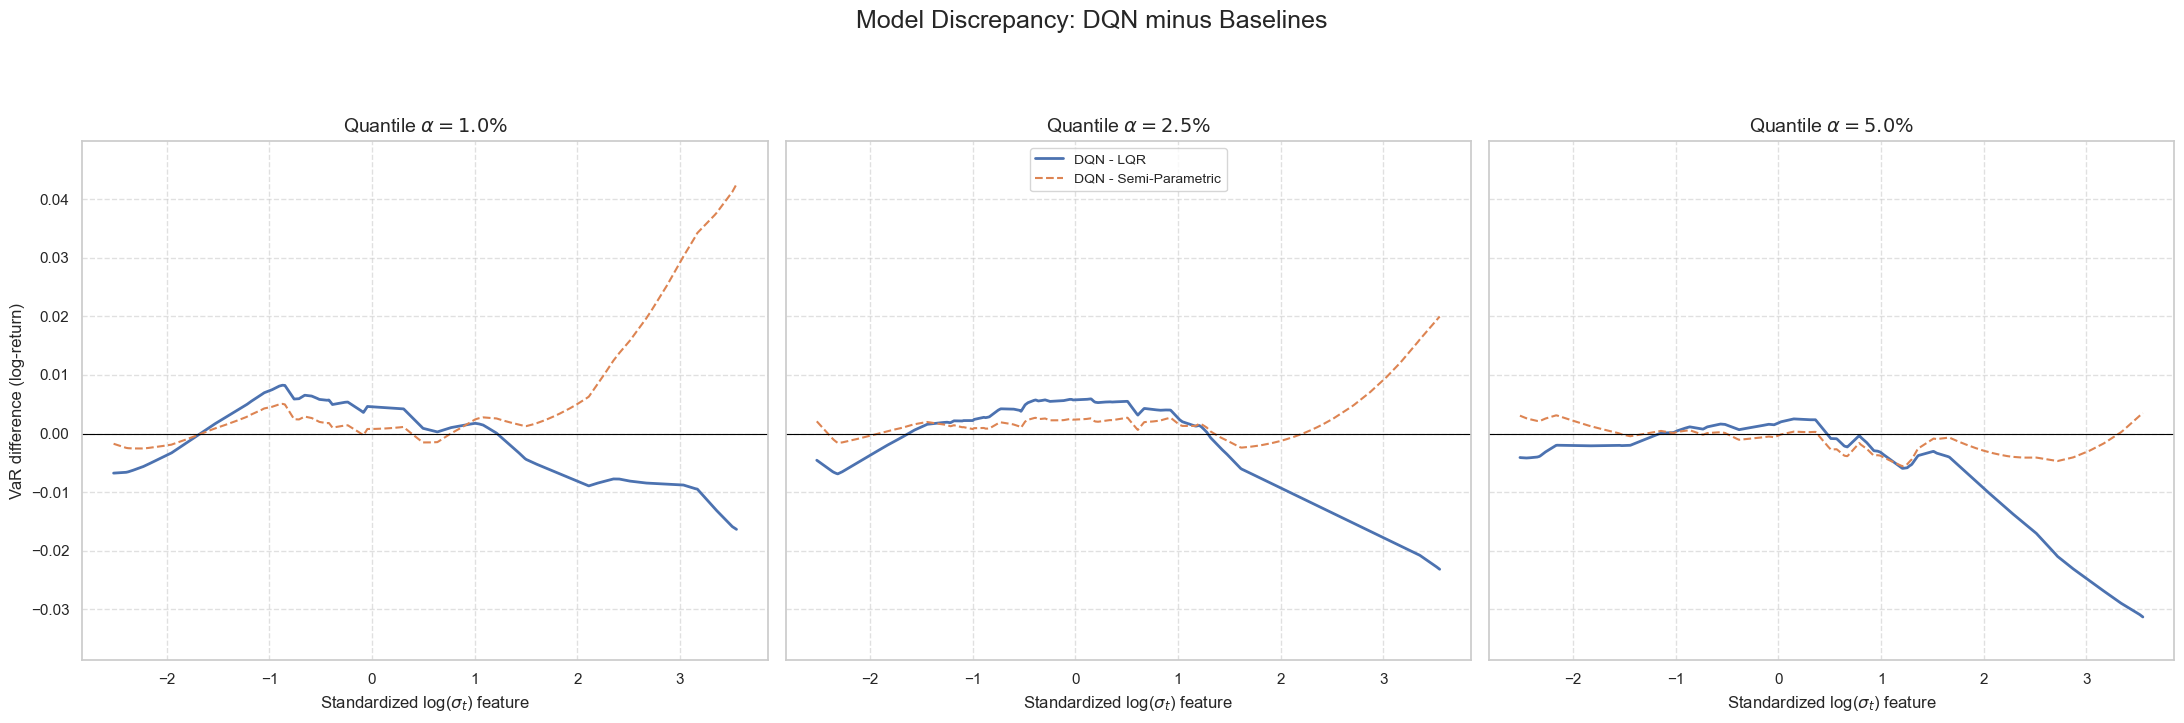

In [21]:
# Ensure column maps exist
alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}
alpha_to_col_lqr   = {a: f"var_lqr_{ALPHA_LABELS[a]}"   for a in ALPHAS}
alpha_to_col_dqn   = {a: f"var_dqn_{ALPHA_LABELS[a]}"   for a in ALPHAS}

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig.suptitle("Model Discrepancy: DQN minus Baselines", fontsize=18, y=1.03)

all_deltas = []

for i, alpha in enumerate(ALPHAS):
    ax = axes[i]
    col_param = alpha_to_col_param[alpha]
    col_lqr   = alpha_to_col_lqr[alpha]
    col_dqn   = alpha_to_col_dqn[alpha]

    if "money_plot_smooth" not in globals() or alpha not in money_plot_smooth:
        raise RuntimeError("Run the money-plot cell before this discrepancy plot.")

    df_raw = money_plot_smooth[alpha]
    x = df_raw["x_sigma_t"].values
    
    # Calculate differences (DQN - Baseline)
    v_param = df_raw[col_param].values
    v_lqr   = df_raw[col_lqr].values
    v_dqn   = df_raw[col_dqn].values

    delta_lqr   = v_dqn - v_lqr
    delta_param = v_dqn - v_param

    all_deltas.append(delta_lqr)
    all_deltas.append(delta_param)

    ax.plot(x, delta_lqr,   linewidth=2.0, linestyle="-",  label="DQN - LQR")
    ax.plot(x, delta_param, linewidth=1.5, linestyle="--", label="DQN - Semi-Parametric")

    ax.axhline(0.0, color="black", linewidth=0.8)

    ax.set_title(fr"Quantile $\alpha = {alpha*100:.1f}\%$", fontsize=14)
    ax.set_xlabel(r"Standardized log($\sigma_t$) feature", fontsize=12)
    if i == 0:
        ax.set_ylabel("VaR difference (log-return)", fontsize=12)

    ax.grid(True, linestyle="--", alpha=0.6)

# Common y-scale across panels for comparability
all_deltas_flat = np.concatenate(all_deltas)
dmin, dmax = all_deltas_flat.min(), all_deltas_flat.max()
pad = 0.1 * (dmax - dmin if dmax > dmin else 1.0)

for ax in axes:
    ax.set_ylim(dmin - pad, dmax + pad)

axes[1].legend(loc="upper center", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 6.5. Bucket-wise Performance Evaluation

Segments the test data into volatility "buckets" (Low to High vol) and calculates Hit Rates and Loss metrics for each bucket to detect if models fail in specific market conditions.

In [22]:
def pinball_loss_np(y_true, q_pred, alpha: float) -> float:
    diff = y_true - q_pred
    loss = np.where(diff < 0.0, (alpha - 1.0) * diff, alpha * diff)
    return float(loss.mean())

# 1. Setup: Calculate Volatility Buckets (Low to High)
cols_common = ["x_sigma_t", "r"]
df_test_eval = features.loc[mask_test, cols_common].copy()

n_buckets = 5

# 1) Compute bucket edges on pre-test (ex-ante) distribution
x_pre = features.loc[mask_pretest, "x_sigma_t"].dropna().values
# Use quantiles to mimic qcut edges, then apply as fixed cut points
bin_edges = np.quantile(x_pre, np.linspace(0, 1, n_buckets + 1))

# Ensure strictly increasing edges (robustness if there are ties)
bin_edges = np.unique(bin_edges)
if len(bin_edges) - 1 < n_buckets:
    raise ValueError(
        f"Not enough unique pre-test quantile edges for {n_buckets} buckets "
        f"(got {len(bin_edges)-1}). Consider fewer buckets or add jitter."
    )

labels = [f"B{i+1}" for i in range(len(bin_edges) - 1)]

# 2) Apply those fixed pre-test edges to the test sample
x = df_test_eval["x_sigma_t"].to_numpy()
x = np.clip(x, bin_edges[0], bin_edges[-1])
df_test_eval["vol_bucket"] = pd.cut(x, bins=bin_edges, labels=labels, include_lowest=True, right=True)

print("Volatility bucket edges (standardised x_sigma_t, pre-test window):")
for k in range(len(bin_edges) - 1):
    print(f" B{k+1}: [{bin_edges[k]:.2f}, {bin_edges[k+1]:.2f}]")
print("-" * 60)

# 2. Iterate and Collect Records
records = []

# Loop over alphas (0.01, 0.025, 0.05)
for alpha in ALPHAS:
    # Identify the specific column names for this alpha
    col_param = alpha_to_col_param[alpha]
    col_lqr   = alpha_to_col_lqr[alpha]
    col_dqn   = alpha_to_col_dqn[alpha]

    models = {
        "EGARCH-skewt": col_param,
        "LQR": col_lqr,
        "DQN": col_dqn,
    }

    # Iterate through each volatility bucket
    for bucket, df_b in df_test_eval.groupby("vol_bucket"):
        n_obs = len(df_b)
        y = df_b["r"].values
        
        # Look up model predictions for this specific subset of rows
        indices = df_b.index

        for model_name, col_name in models.items():
            q = features.loc[indices, col_name].values

            # Calculate Metrics
            exceed = y < q
            hit_rate = float(exceed.mean())
            pl = pinball_loss_np(y, q, alpha)
            
            # Expected Shortfall (realised) in this bucket
            es_realised = float(y[exceed].mean()) if exceed.any() else np.nan

            records.append({
                "alpha": alpha,
                "bucket": bucket,
                "model": model_name,
                "hit_rate": hit_rate,
                "pinball_loss": pl,
                "realised_shortfall": es_realised
            })

# 3. Create and Format Pivot Tables
df_results = pd.DataFrame(records)

def create_pivot(value_col):
    return df_results.pivot(
        index="bucket",
        columns=["alpha", "model"],
        values=value_col
    )

table_hit  = create_pivot("hit_rate")
table_loss = create_pivot("pinball_loss")
table_es   = create_pivot("realised_shortfall")

# 4. Display Results
print("\n>>> HIT RATE (Target: 0.01, 0.025, 0.05)")
display(table_hit.style.format("{:.3f}"))

print("\n>>> PINBALL LOSS (Lower is better)")
display(table_loss.style.format("{:.2e}"))

print("\n>>> REALISED SHORTFALL (Mean return of exceedances)")
display(table_es.style.format("{:.4f}"))

Volatility bucket edges (standardised x_sigma_t, pre-test window):
 B1: [-2.29, -0.93]
 B2: [-0.93, -0.27]
 B3: [-0.27, 0.23]
 B4: [0.23, 0.79]
 B5: [0.79, 3.56]
------------------------------------------------------------

>>> HIT RATE (Target: 0.01, 0.025, 0.05)



>>> PINBALL LOSS (Lower is better)



>>> REALISED SHORTFALL (Mean return of exceedances)


In [23]:
# Debug: compare B5 exceedance dates across models

alpha_to_col_param = {a: f"var_param_{ALPHA_LABELS[a]}" for a in ALPHAS}
alpha_to_col_lqr   = {a: f"var_lqr_{ALPHA_LABELS[a]}"   for a in ALPHAS}
alpha_to_col_dqn   = {a: f"var_dqn_{ALPHA_LABELS[a]}"   for a in ALPHAS}

b5 = df_test_eval[df_test_eval["vol_bucket"] == "B5"].copy()
print("B5 obs:", len(b5))

for a in ALPHAS:
    cols = {
        "Benchmark": alpha_to_col_param[a],
        "LQR":       alpha_to_col_lqr[a],
        "DQN":       alpha_to_col_dqn[a],
    }

    y = b5["r"]
    breach_sets = {}

    for name, col in cols.items():
        q = features.loc[b5.index, col]          # keep as Series aligned by index
        exceed = (y < q)
        breach_sets[name] = set(b5.index[exceed])

        print(f"alpha={a:0.3f} | {name:9s} | n_exc={exceed.sum():3d} | hit={exceed.mean():.4%}")

    # Pairwise set comparisons
    names = list(breach_sets.keys())
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            A, B = names[i], names[j]
            inter = len(breach_sets[A] & breach_sets[B])
            symm  = len(breach_sets[A] ^ breach_sets[B])
            print(f"    {A} vs {B}: intersection={inter}, symmetric_diff={symm}")

    for name in names:
        if len(breach_sets[name]) <= 5:
            print(f"    breach dates ({name}): {sorted(breach_sets[name])}")

    print("-"*70)


B5 obs: 206
alpha=0.010 | Benchmark | n_exc=  2 | hit=0.9709%
alpha=0.010 | LQR       | n_exc=  2 | hit=0.9709%
alpha=0.010 | DQN       | n_exc=  2 | hit=0.9709%
    Benchmark vs LQR: intersection=2, symmetric_diff=0
    Benchmark vs DQN: intersection=2, symmetric_diff=0
    LQR vs DQN: intersection=2, symmetric_diff=0
    breach dates (Benchmark): [Timestamp('2020-03-09 00:00:00'), Timestamp('2020-03-12 00:00:00')]
    breach dates (LQR): [Timestamp('2020-03-09 00:00:00'), Timestamp('2020-03-12 00:00:00')]
    breach dates (DQN): [Timestamp('2020-03-09 00:00:00'), Timestamp('2020-03-12 00:00:00')]
----------------------------------------------------------------------
alpha=0.025 | Benchmark | n_exc=  4 | hit=1.9417%
alpha=0.025 | LQR       | n_exc=  4 | hit=1.9417%
alpha=0.025 | DQN       | n_exc=  3 | hit=1.4563%
    Benchmark vs LQR: intersection=4, symmetric_diff=0
    Benchmark vs DQN: intersection=3, symmetric_diff=1
    LQR vs DQN: intersection=3, symmetric_diff=1
    breach dat

In the highest-volatility bucket (B5), tail events at α=1% are extremely sparse, with only 2 exceedances out of 206 observations. These exceedances occur on the same March-2020 crash dates across all methods, so the exceedance sets coincide exactly. As a result, both the B5 hit rate and the realised shortfall are mechanically identical across models, because they are computed from the same two return observations. This does not imply identical VaR forecasts—VaR levels still differ across models—but inference about model differences at α=1% in B5 is limited by the tiny effective tail sample.

## 7. Plots for the Seminar Paper

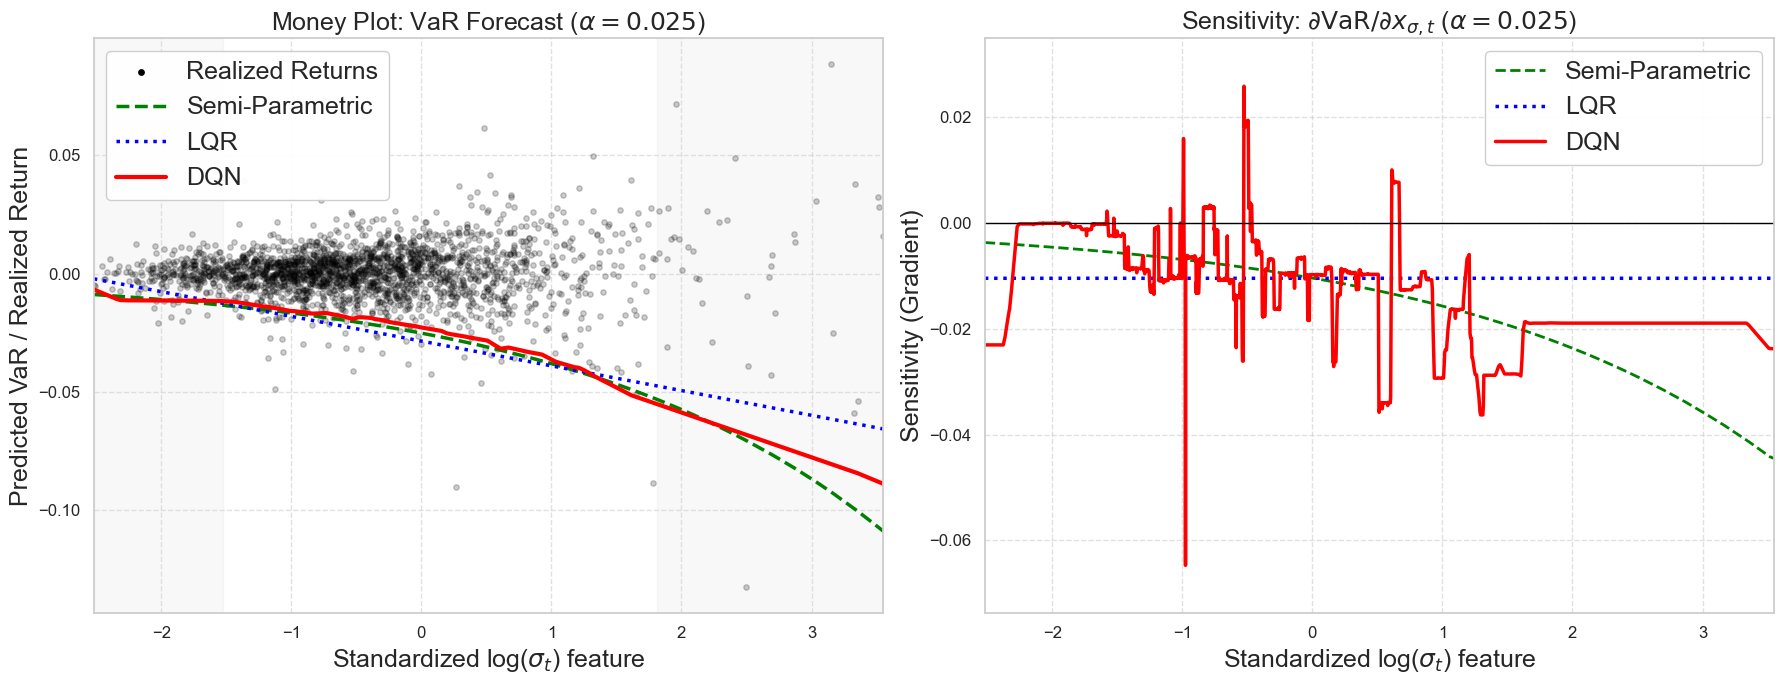

In [24]:
import numpy as np
import matplotlib.pyplot as plt

features_pretest = features.loc[mask_pretest].copy()

# Configuration
target_alpha = 0.025
alpha_label_str = f"{target_alpha*100:.1f}%"

# Setup Figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 
plt.subplots_adjust(wspace=0.25)

df_raw = features_test.copy().sort_values(by="x_sigma_t")

x = df_raw["x_sigma_t"].values
y_returns = df_raw["r"].values

# Retrieve columns dynamically for the target alpha
v_param = df_raw[alpha_to_col_param[target_alpha]].values
v_lqr   = df_raw[alpha_to_col_lqr[target_alpha]].values
v_dqn   = df_raw[alpha_to_col_dqn[target_alpha]].values

# Data for shading (Data Scarce Regions)
q_low  = features_pretest["x_sigma_t"].quantile(0.05)
q_high = features_pretest["x_sigma_t"].quantile(0.95)
x_min, x_max = x.min(), x.max()

# PLOT 1: The "Money Plot" (VaR vs Volatility) with Return Scatter
ax1 = axes[0]

# 1.1 Shade data-scarce regions
ax1.axvspan(x_min, q_low, color="lightgrey", alpha=0.15)
ax1.axvspan(q_high, x_max, color="lightgrey", alpha=0.15)

# 1.2 Scatter of Realized Returns (The "Cloud")
# Plot actual points with transparency and NO label
ax1.scatter(x, y_returns, color="black", alpha=0.2, s=15, zorder=1, label=None)

# Plot a "Ghost" point for the Legend (fully opaque)
ax1.scatter([], [], color="black", alpha=1.0, s=15, label="Realized Returns")

# 1.3 Main VaR Curves
ax1.plot(x, v_param, label="Semi-Parametric", color="green", linestyle="--", linewidth=2.5, zorder=2)
ax1.plot(x, v_lqr,   label="LQR",        color="blue",  linestyle=":",  linewidth=2.5, zorder=2)
ax1.plot(x, v_dqn,   label="DQN",  color="red",   linestyle="-", linewidth=3.0, zorder=2)

# 1.4 Formatting
ax1.set_xlim(x_min, x_max)
ax1.set_title(fr"Money Plot: VaR Forecast ($\alpha={target_alpha}$)", fontsize=18)
ax1.set_xlabel(r"Standardized log($\sigma_t$) feature", fontsize=18)
ax1.set_ylabel("Predicted VaR / Realized Return", fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=12) 
ax1.grid(True, linestyle="--", alpha=0.6)

ax1.legend(loc="upper left", fontsize=18, framealpha=0.95)

# PLOT 2: Local Sensitivity (Gradients)
ax2 = axes[1]

# 2.1 Calculate Numerical Gradients (dVaR / dSigma)
g_param = np.gradient(v_param, x)
g_lqr   = np.gradient(v_lqr, x)
g_dqn   = np.gradient(v_dqn, x)

# 2.2 Gradient Curves
ax2.plot(x, g_param, label="Semi-Parametric", color="green", linestyle="--", linewidth=2.0)
ax2.plot(x, g_lqr,   label="LQR",        color="blue",  linestyle=":",  linewidth=2.5)
ax2.plot(x, g_dqn,   label="DQN",        color="red",   linestyle="-", linewidth=2.5)

# 2.3 Formatting
ax2.axhline(0.0, color="black", linewidth=1.0)
ax2.set_xlim(x_min, x_max)
ax2.set_title(fr"Sensitivity: $\partial \mathrm{{VaR}} / \partial x_{{\sigma,t}}$ ($\alpha={target_alpha}$)", fontsize=18)
ax2.set_xlabel(r"Standardized log($\sigma_t$) feature", fontsize=18)
ax2.set_ylabel(r"Sensitivity (Gradient)", fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, linestyle="--", alpha=0.6)

# Legend in UPPER RIGHT with larger font
ax2.legend(loc="upper right", fontsize=18, framealpha=0.95)

# 2.4 Align Y-limits
all_grads = np.concatenate([g_param, g_lqr, g_dqn])
gmin, gmax = all_grads.min(), all_grads.max()
pad = 0.1 * (gmax - gmin) if gmax > gmin else 1.0
ax2.set_ylim(gmin - pad, gmax + pad)

plt.tight_layout()
plt.show()